# Homework 5

The purpose of this homework is to give you experience with different aspects of CNN's.  This is a big and complex field with too much to possibly learn in a few weeks, but this will hopefully give you some places to start learning and experimenting.

We are going to download some sets of images and see if we can construct a good classifier for the images.  The images should be emperor, king and chinstrap penguins.

We are going to construct two different CNN classifiers from scratch, then use a pretrained model.  We will compare the accuracy of the three models.

# Part a

Download a set of three penguin image sets, 200 images each using google (https://pypi.org/project/google_images_download/) or bing_image_downloader (https://pypi.org/project/bing-image-downloader/).  The images should be of chinstrap, emperor and king penguins.

from bing_image_downloader import downloader

query_string = 'chinstrap penguin'

downloader.download(query_string, limit=200,  output_dir='dataset', adult_filter_off=False, force_replace=False, timeout=60, verbose=True)

Now download emperor penguins, then king penguins.

Create a directory called dataset.  Under that directory, you will download your three sets of images, 200 images per set, one directory for each set.  Use the following code to preprocess your images.

In [20]:
# Importing important packages
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from keras.layers import Dropout, Dense, Flatten, BatchNormalization, GlobalAveragePooling2D
from keras.models import Sequential
from keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers
from tensorflow.keras.optimizers import RMSprop
import matplotlib.pyplot as plt
import os
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.applications.resnet import preprocess_input
%matplotlib inline

In [ ]:
print("cwd:", os.getcwd())
data_dir = '/Users/magmac/Downloads/penguins'

# keep only real subfolders -> ignore files like (.DS_Store)
Name = [d for d in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, d)) and not d.startswith('.')]

print("Class folders found:", Name)
print("Number of classes:", len(Name))

N = list(range(len(Name)))
normal_mapping  = dict(zip(Name, N))
reverse_mapping = dict(zip(N, Name))

print("normal_mapping :", normal_mapping)
print("reverse_mapping:", reverse_mapping)

if len(Name) != 3:
    print("*** Expected 3 class folders (gentoo, chinstrap, adelie). Check your data_dir. ***")

cwd: /Users/magmac/Downloads
Class folders found: ['chinstrap penguin', 'gentoo penguin', 'adelie penguin']
Number of classes: 3
normal_mapping : {'chinstrap penguin': 0, 'gentoo penguin': 1, 'adelie penguin': 2}
reverse_mapping: {0: 'chinstrap penguin', 1: 'gentoo penguin', 2: 'adelie penguin'}


In [ ]:
preprocess_input = tf.keras.applications.resnet.preprocess_input

# Rescaling removed to avoid double-normalization with preprocess_input (ResNet)
train_datagen = ImageDataGenerator(
        validation_split=0.2,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest',
        preprocessing_function=preprocess_input
)

validation_datagen = ImageDataGenerator(
        validation_split=0.2,
        preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(255, 255),      # can switch to (224,224)
    class_mode='categorical',
    batch_size=6,
    subset="training",
    shuffle=True,
    seed=42
)

validation_generator = validation_datagen.flow_from_directory(
    data_dir,
    target_size=(255, 255),
    class_mode='categorical',
    batch_size=6,
    subset="validation",
    shuffle=False,
    seed=42
)

Found 494 images belonging to 3 classes.
Found 123 images belonging to 3 classes.


# Part b
Now build a simple CNN using the template below.  The images are 255x255 pixels with three colors.  Plot the training and validation loss and accuracy per epoch.

In [9]:
model = tf.keras.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape = (255, 255, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
# don't forget to add an activation function to the output layer
model.add(layers.Dense(3))

/Users/magmac/Downloads/.venv/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-21 17:44:16.732150: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2025-10-21 17:44:16.732217: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-10-21 17:44:16.732239: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-10-21 17:44:16.732282: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-10-21 17:44:16.732303: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 253, 253, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 124, 124, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 230400)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │    14,745,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,802,179 (56.47 MB)

 Trainable params: 14,802,179 (56.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
83/83 - 6s - 76ms/step - accuracy: 0.3381 - loss: 1208.0504 - val_accuracy: 0.3984 - val_loss: 1088.4111
Epoch 2/15
83/83 - 6s - 68ms/step - accuracy: 0.3016 - loss: 977.7374 - val_accuracy: 0.3252 - val_loss: 723.9791
Epoch 3/15
83/83 - 5s - 65ms/step - accuracy: 0.3036 - loss: 847.4857 - val_accuracy: 0.3740 - val_loss: 523.8738
Epoch 4/15
83/83 - 5s - 65ms/step - accuracy: 0.3279 - loss: 1147.7849 - val_accuracy: 0.3089 - val_loss: 700.2736
Epoch 5/15
83/83 - 5s - 65ms/step - accuracy: 0.3866 - loss: 1378.4624 - val_accuracy: 0.3740 - val_loss: 2000.9514
Epoch 6/15
83/83 - 5s - 65ms/step - accuracy: 0.3603 - loss: 1507.4514 - val_accuracy: 0.4715 - val_loss: 943.9257
Epoch 7/15
83/83 - 5s - 65ms/step - accuracy: 0.3360 - loss: 1033.1207 - val_accuracy: 0.4065 - val_loss: 777.1134
Epoch 8/15
83/83 - 5s - 65ms/step - accuracy: 0.3320 - loss: 848.0827 - val_accuracy: 0.4146 - val_loss: 1504.8676
Epoch 9/15
83/83 - 5s - 65ms/step - accuracy: 0.3644 - loss: 1463.5681 - val_acc

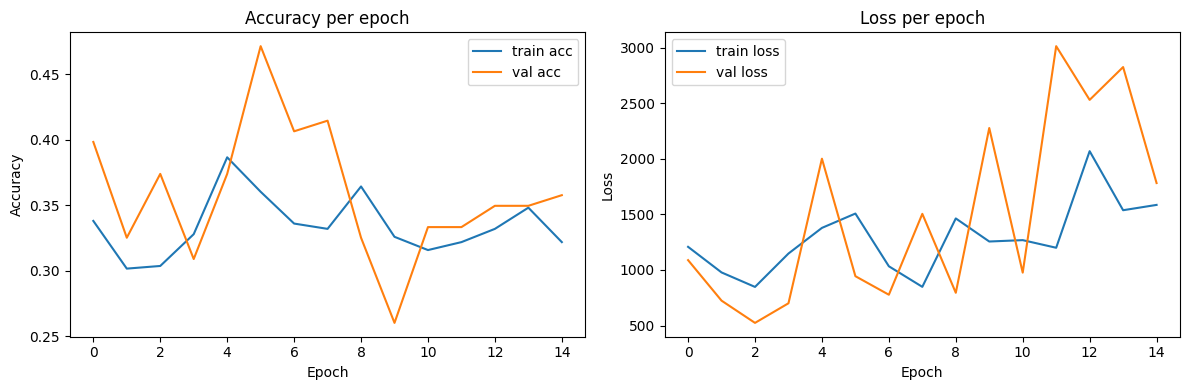

In [ ]:
# Improved version
model = tf.keras.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(255, 255, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
# add an activation function to the output layer
model.add(layers.Dense(3, activation='softmax'))

model.summary()

# compile (categorical labels from generators)
model.compile(
    optimizer=RMSprop(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# train
EPOCHS = 15  # adjust if needed
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    verbose=2
)

# plot training & validation curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy per epoch'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss per epoch'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.show()


# Part c
This model did not work very well.  Improve the model without using a pre-trained model.  Explain why you made the changes to the model.  Plot the training and validation loss and accuracy per epoch.  Don't go crazy and add so many layers and filters that it takes a week to train.  Keep it reasonable.

Also, change the callbacks so it does early stopping when the validation accuracy stops improving four epochs in a row.  Only save the best model, not the last model.

Found 494 images belonging to 3 classes.
Found 123 images belonging to 3 classes.


Model: "scratch_cnn_improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 255, 255, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 255, 255, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 255, 255, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 255, 255, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 127, 127, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 127, 127, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 127, 127, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 127, 127, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 63, 63, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 63, 63, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,603 (615.64 KB)

 Trainable params: 156,963 (613.14 KB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/25

Epoch 1: val_accuracy improved from -inf to 0.28455, saving model to model_scratch_best.keras
83/83 - 12s - 145ms/step - accuracy: 0.3623 - loss: 1.5816 - val_accuracy: 0.2846 - val_loss: 1.4827 - learning_rate: 0.0010
Epoch 2/25

Epoch 2: val_accuracy improved from 0.28455 to 0.30894, saving model to model_scratch_best.keras
83/83 - 10s - 117ms/step - accuracy: 0.3543 - loss: 1.4213 - val_accuracy: 0.3089 - val_loss: 3.0504 - learning_rate: 0.0010
Epoch 3/25

Epoch 3: val_accuracy improved from 0.30894 to 0.38211, saving model to model_scratch_best.keras
83/83 - 10s - 119ms/step - accuracy: 0.3907 - loss: 1.3235 - val_accuracy: 0.3821 - val_loss: 1.1413 - learning_rate: 0.0010
Epoch 4/25

Epoch 4: val_accuracy did not improve from 0.38211
83/83 - 10s - 121ms/step - accuracy: 0.3806 - loss: 1.2819 - val_accuracy: 0.3577 - val_loss: 1.1277 - learning_rate: 0.0010
Epoch 5/25

Epoch 5: val_accuracy improved from 0.38211 to 0.46341, saving model to model_scratch_best.keras
83/8

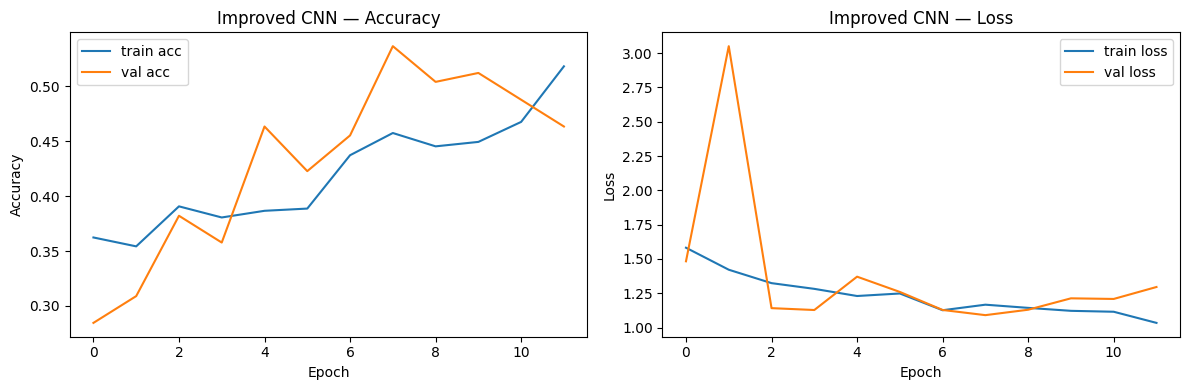

Best model saved to: model_scratch_best.keras


In [14]:
# Scratch-only generators with simple rescale (no ResNet preprocess), same split as before

IMG_SIZE   = (255, 255)
BATCH_SIZE = 6
VAL_SPLIT  = 0.2

train_datagen_simple = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen_simple = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT
)

train_gen_simple = train_datagen_simple.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    subset="training",
    shuffle=True,
    seed=42
)

val_gen_simple = val_datagen_simple.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    subset="validation",
    shuffle=False,
    seed=42
)

#print("class_indices:", train_gen_simple.class_indices)


NUM_CLASSES = train_gen_simple.num_classes  # use simple [0,1]-scaled generators from previous step
INPUT_SHAPE = (255, 255, 3)

def build_improved_cnn():
    he = HeNormal()
    m = Sequential(name="scratch_cnn_improved")

    # Block 1
    m.add(Conv2D(32, (3,3), padding='same', activation='relu', kernel_initializer=he, input_shape=INPUT_SHAPE))
    m.add(BatchNormalization())
    m.add(Conv2D(32, (3,3), padding='same', activation='relu', kernel_initializer=he))
    m.add(BatchNormalization())
    m.add(MaxPooling2D())

    # Block 2
    m.add(Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he))
    m.add(BatchNormalization())
    m.add(Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he))
    m.add(BatchNormalization())
    m.add(MaxPooling2D())

    # Block 3 (slightly larger features)
    m.add(Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he))
    m.add(BatchNormalization())
    m.add(MaxPooling2D())

    # Compact head
    m.add(GlobalAveragePooling2D())      # replaces Flatten -> huge Dense
    m.add(Dropout(0.4))
    m.add(Dense(128, activation='relu', kernel_initializer=he))
    m.add(Dropout(0.3))
    m.add(Dense(NUM_CLASSES, activation='softmax'))
    return m

model_c = build_improved_cnn()
model_c.summary()

model_c.compile(
    optimizer=RMSprop(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Required callbacks
ckpt_path = "model_scratch_best.keras"
cb_early = EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True, verbose=1)
cb_ckpt  = ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True, verbose=1)
cb_rlrop = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1)

EPOCHS = 25  # EarlyStopping will cut it earlier if no improvement

history_c = model_c.fit(
    train_gen_simple,
    validation_data=val_gen_simple,
    epochs=EPOCHS,
    callbacks=[cb_early, cb_ckpt, cb_rlrop],
    verbose=2
)

# Plots
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_c.history['accuracy'], label='train acc')
plt.plot(history_c.history['val_accuracy'], label='val acc')
plt.title('Improved CNN — Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history_c.history['loss'], label='train loss')
plt.plot(history_c.history['val_loss'], label='val loss')
plt.title('Improved CNN — Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout(); plt.show()

print("Best model saved to:", ckpt_path)

# Part d

Plot the first 6 images in the validation dataset.  Set the title of the plot to show the predicted category and the actual category

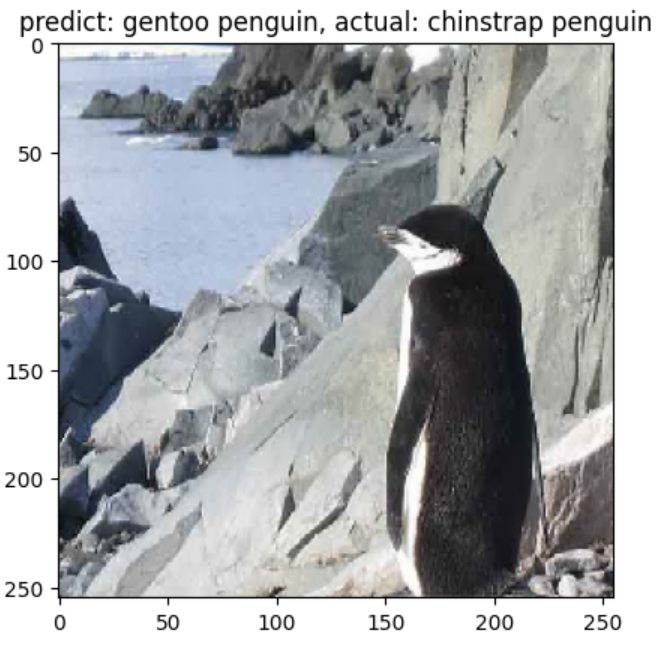

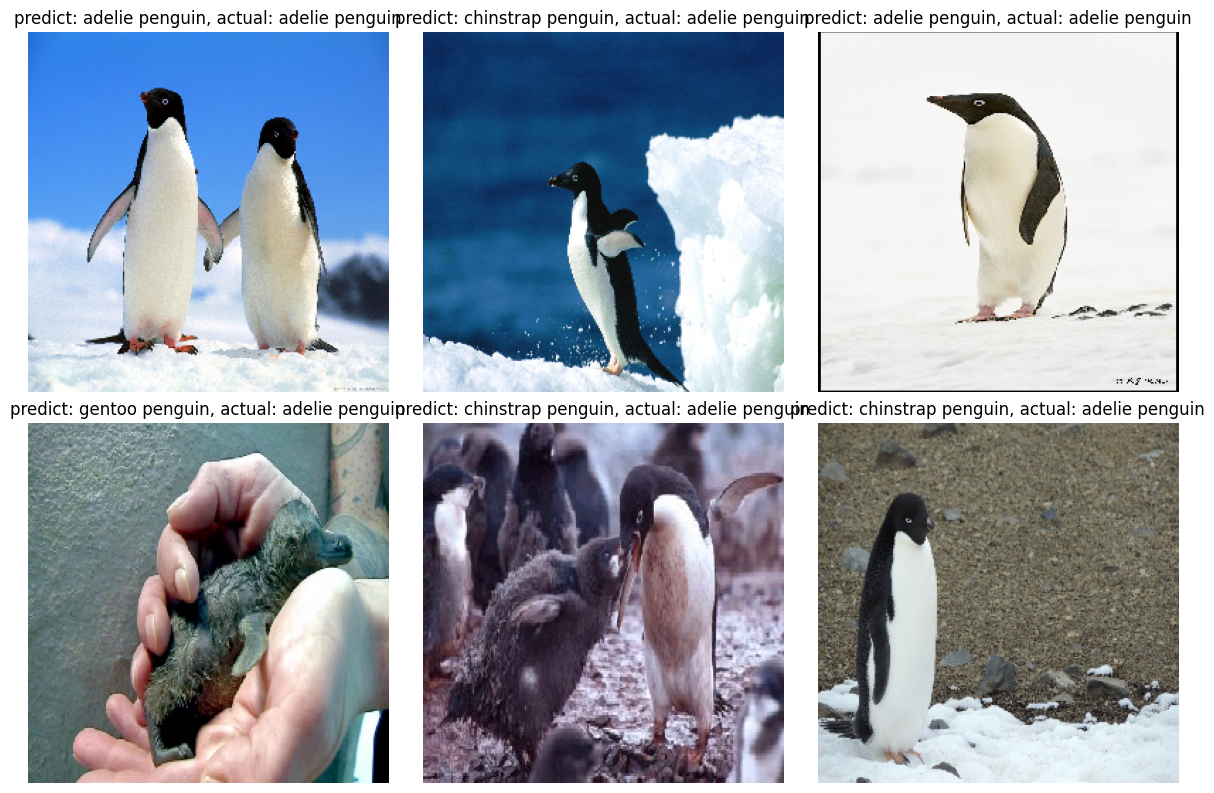

In [15]:
# start at the first batch and keep the fixed val order
val_gen_simple.reset()
x_batch, y_true = next(val_gen_simple)   # first batch from validation set (shuffle=False)
y_prob = model_c.predict(x_batch, verbose=0)
y_pred = y_prob.argmax(axis=1)

# index -> class name mapping
idx_to_class = {v: k for k, v in val_gen_simple.class_indices.items()}

plt.figure(figsize=(12, 8))
for i in range(6):
    ax = plt.subplot(2, 3, i+1)
    # reverse the [0,1] rescale for better display
    img = (x_batch[i] * 255).astype("uint8")
    true_idx = int(np.argmax(y_true[i]))
    pred_idx = int(y_pred[i])
    plt.imshow(img)
    plt.title(f"predict: {idx_to_class[pred_idx]}, actual: {idx_to_class[true_idx]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# Part e

Use a pretrained model to improve your results.  Pick any pretrained model that is in the Keras library.  

https://keras.io/api/applications/

Create at least two models using the same pretrained model but with different final layers to see which one works best.  Use early stopping.  Plot the training and validation accuracy and loss.  Plot the first 6 images from the validation datset to show the actual vs predicted names.

In [17]:
NUM_CLASSES = train_generator.num_classes

def make_resnet50_model(head="A"):
    base = ResNet50(include_top=False, weights="imagenet",
                    input_tensor=Input(shape=(255,255,3)))
    base.trainable = False  # warm-up with frozen backbone

    x = base.output
    x = GlobalAveragePooling2D(name="gap")(x)

    if head == "A":
        # Head A: small, regularized
        x = Dropout(0.3)(x)
        out = Dense(NUM_CLASSES, activation="softmax", name="predictions")(x)
    else:
        # Head B: a bit larger with BN + Dropout
        x = Dense(256, activation="relu")(x)
        x = BatchNormalization()(x)
        x = Dropout(0.5)(x)
        out = Dense(NUM_CLASSES, activation="softmax", name="predictions")(x)

    model = Model(inputs=base.input, outputs=out, name=f"resnet50_head_{head}")
    return model

model_A = make_resnet50_model("A")
model_B = make_resnet50_model("B")

for m in (model_A, model_B):
    m.compile(optimizer=RMSprop(learning_rate=1e-3),
              loss="categorical_crossentropy",
              metrics=["accuracy"])
    m.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "resnet50_head_A"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 255, 255,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 261, 261,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 6,147 (24.01 KB)

...

Model: "resnet50_head_B"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 255, 255,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 261, 261,  │          0 │ input_layer_6[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 24,114,051 (91.99 MB)

 Trainable params: 525,827 (2.01 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

Epoch 1/7


/Users/magmac/Downloads/.venv/lib/python3.9/site-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")



Epoch 1: val_accuracy improved from -inf to 0.86179, saving model to best_resnet_headA.keras
83/83 - 11s - 137ms/step - accuracy: 0.8947 - loss: 0.2814 - val_accuracy: 0.8618 - val_loss: 0.3748 - learning_rate: 0.0010
Epoch 2/7

Epoch 2: val_accuracy did not improve from 0.86179
83/83 - 6s - 77ms/step - accuracy: 0.8765 - loss: 0.3335 - val_accuracy: 0.8618 - val_loss: 0.3748 - learning_rate: 0.0010
Epoch 3/7

Epoch 3: val_accuracy did not improve from 0.86179

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
83/83 - 6s - 78ms/step - accuracy: 0.8927 - loss: 0.3085 - val_accuracy: 0.8618 - val_loss: 0.3748 - learning_rate: 0.0010
Epoch 4/7

Epoch 4: val_accuracy did not improve from 0.86179
83/83 - 6s - 77ms/step - accuracy: 0.8947 - loss: 0.3245 - val_accuracy: 0.8618 - val_loss: 0.3748 - learning_rate: 5.0000e-04
Epoch 5/7

Epoch 5: val_accuracy did not improve from 0.86179

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
83/83 

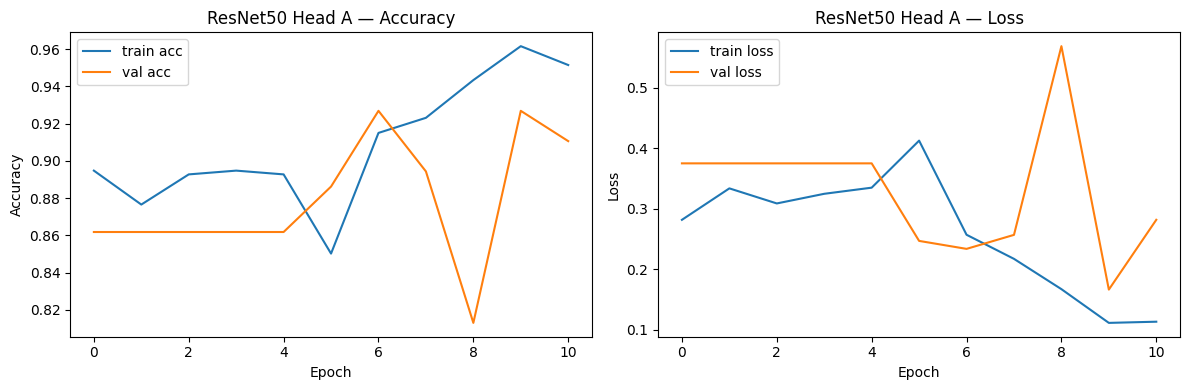

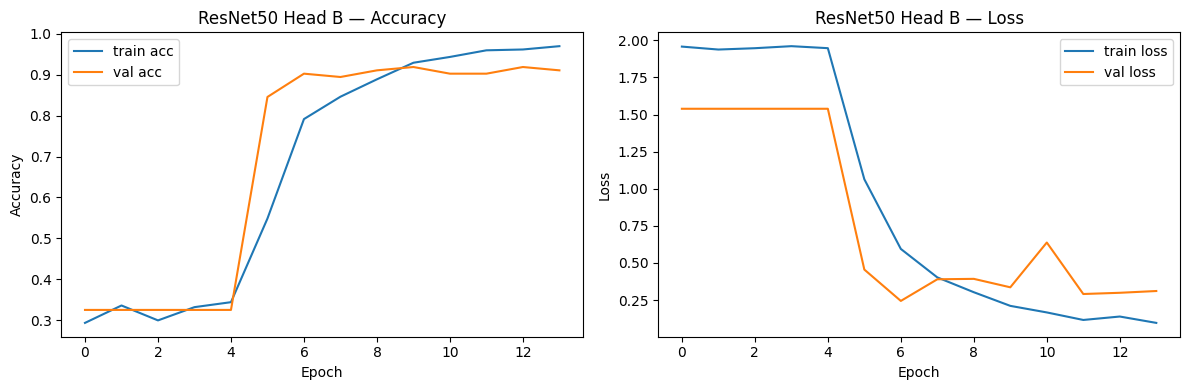

Best head: A  (A: 0.927, B: 0.919)


In [19]:
def train_with_callbacks(model, ckpt_name, train_gen, val_gen,
                         warmup_epochs=7, finetune_epochs=12, unfreeze_tail=20):
    """
    Warm-up with backbone frozen, then fine-tune by unfreezing a small tail
    of the full model (skipping BatchNorms for stability).
    """
    # Warm-up: freeze all layers
    for layer in model.layers:
        layer.trainable = False

    model.compile(optimizer=RMSprop(learning_rate=1e-3),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])

    cb_early = EarlyStopping(monitor="val_accuracy", patience=4,
                             restore_best_weights=True, verbose=1)
    cb_ckpt  = ModelCheckpoint(ckpt_name, monitor="val_accuracy",
                               save_best_only=True, verbose=1)
    cb_rlr   = ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                 patience=2, verbose=1)

    h1 = model.fit(train_gen,
                   validation_data=val_gen,
                   epochs=warmup_epochs,
                   callbacks=[cb_early, cb_ckpt, cb_rlr],
                   verbose=2)

    # Fine-tune: unfreeze a small tail (skip BatchNorm layers)
    for layer in model.layers:
        layer.trainable = False

    unfrozen = 0
    for layer in reversed(model.layers):
        # keep BN layers frozen; they can destabilize on small datasets
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            continue
        layer.trainable = True
        unfrozen += 1
        if unfrozen >= unfreeze_tail:
            break

    model.compile(optimizer=RMSprop(learning_rate=1e-4),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])

    h2 = model.fit(train_gen,
                   validation_data=val_gen,
                   epochs=finetune_epochs,
                   callbacks=[cb_early, cb_ckpt, cb_rlr],
                   verbose=2)

    # merge histories for plotting
    keys = set(h1.history.keys()) | set(h2.history.keys())
    history = {k: h1.history.get(k, []) + h2.history.get(k, []) for k in keys}
    return history

def plot_history(hist, title):
    plt.figure(figsize=(12,4))
    # accuracy
    plt.subplot(1,2,1)
    plt.plot(hist.get('accuracy', []), label='train acc')
    plt.plot(hist.get('val_accuracy', []), label='val acc')
    plt.title(f'{title} — Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
    # loss
    plt.subplot(1,2,2)
    plt.plot(hist.get('loss', []), label='train loss')
    plt.plot(hist.get('val_loss', []), label='val loss')
    plt.title(f'{title} — Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    plt.tight_layout(); plt.show()

# Train both heads you already built above: model_A, model_B
hist_A = train_with_callbacks(model_A, "best_resnet_headA.keras",
                              train_generator, validation_generator)
hist_B = train_with_callbacks(model_B, "best_resnet_headB.keras",
                              train_generator, validation_generator)

# Plot
plot_history(hist_A, "ResNet50 Head A")
plot_history(hist_B, "ResNet50 Head B")

# Pick best by max val_accuracy
best_A = max(hist_A.get('val_accuracy', [0]))
best_B = max(hist_B.get('val_accuracy', [0]))
best_name = "A" if best_A >= best_B else "B"
print(f"Best head: {best_name}  (A: {best_A:.3f}, B: {best_B:.3f})")


# Part f
Next try not doing data augmentation on your best model from part e.  Reprocess the data but this time do not do any data augmentation.

Plot the training and validation loss and accuracy and compare to your best model with augmentation.

Best head from Part e: A  |  Augmented best val acc = 0.927
Found 494 images belonging to 3 classes.
Found 123 images belonging to 3 classes.
Epoch 1/7


/Users/magmac/Downloads/.venv/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_accuracy improved from -inf to 0.31707, saving model to best_resnet_headA_NOAUG.keras
83/83 - 12s - 146ms/step - accuracy: 0.3482 - loss: 1.3930 - val_accuracy: 0.3171 - val_loss: 1.2764 - learning_rate: 0.0010
Epoch 2/7

Epoch 2: val_accuracy did not improve from 0.31707
83/83 - 6s - 77ms/step - accuracy: 0.3502 - loss: 1.3856 - val_accuracy: 0.3171 - val_loss: 1.2764 - learning_rate: 0.0010
Epoch 3/7

Epoch 3: val_accuracy did not improve from 0.31707

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
83/83 - 6s - 78ms/step - accuracy: 0.3563 - loss: 1.3981 - val_accuracy: 0.3171 - val_loss: 1.2764 - learning_rate: 0.0010
Epoch 4/7

Epoch 4: val_accuracy did not improve from 0.31707
83/83 - 6s - 77ms/step - accuracy: 0.3502 - loss: 1.4177 - val_accuracy: 0.3171 - val_loss: 1.2764 - learning_rate: 5.0000e-04
Epoch 5/7

Epoch 5: val_accuracy did not improve from 0.31707

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


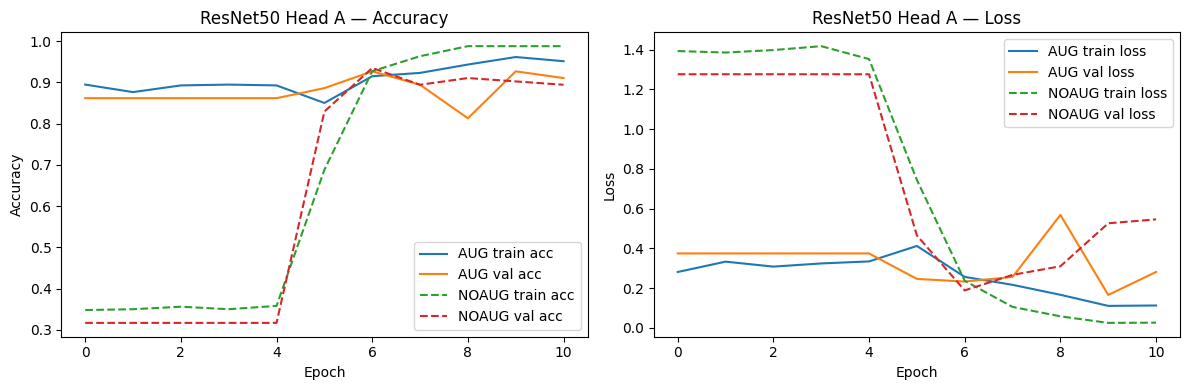

Best val acc — AUG: 0.927   |   NOAUG: 0.935


In [21]:
# Identify the best head & its history from Part e
best_head = "A" if max(hist_A.get('val_accuracy', [0])) >= max(hist_B.get('val_accuracy', [0])) else "B"
hist_aug  = hist_A if best_head == "A" else hist_B
print(f"Best head from Part e: {best_head}  |  Augmented best val acc = {max(hist_aug['val_accuracy']):.3f}")

# Build generators WITHOUT data augmentation (still use ResNet preprocess)
IMG_SIZE   = (255, 255)
BATCH_SIZE = 6
VAL_SPLIT  = 0.20

train_gen_noaug = ImageDataGenerator(
    validation_split=VAL_SPLIT,
    preprocessing_function=preprocess_input  # no rescale and no aug
).flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    subset="training",
    shuffle=True,
    seed=42
)

val_gen_noaug = ImageDataGenerator(
    validation_split=VAL_SPLIT,
    preprocessing_function=preprocess_input  # no rescale and no aug
).flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    subset="validation",
    shuffle=False,
    seed=42
)

# Rebuild the SAME pretrained architecture as your winner from Part e
model_noaug = make_resnet50_model(best_head)  # uses same function defined in Part e

# Train it with the same two-phase schedule/callbacks used in Part e
hist_noaug = train_with_callbacks(
    model_noaug,
    ckpt_name=f"best_resnet_head{best_head}_NOAUG.keras",
    train_gen=train_gen_noaug,
    val_gen=val_gen_noaug,
    warmup_epochs=7,
    finetune_epochs=12,
    unfreeze_tail=20
)

# Plot: overlay NO-AUG vs AUG histories for direct comparison
def overlay_histories(hist_aug, hist_noaug, title_prefix):
    plt.figure(figsize=(12,4))
    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(hist_aug['accuracy'], label='AUG train acc')
    plt.plot(hist_aug['val_accuracy'], label='AUG val acc')
    plt.plot(hist_noaug['accuracy'], label='NOAUG train acc', linestyle='--')
    plt.plot(hist_noaug['val_accuracy'], label='NOAUG val acc', linestyle='--')
    plt.title(f'{title_prefix} — Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
    # Loss
    plt.subplot(1,2,2)
    plt.plot(hist_aug['loss'], label='AUG train loss')
    plt.plot(hist_aug['val_loss'], label='AUG val loss')
    plt.plot(hist_noaug['loss'], label='NOAUG train loss', linestyle='--')
    plt.plot(hist_noaug['val_loss'], label='NOAUG val loss', linestyle='--')
    plt.title(f'{title_prefix} — Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    plt.tight_layout(); plt.show()

overlay_histories(hist_aug, hist_noaug, f"ResNet50 Head {best_head}")

# Quick numeric comparison
best_aug   = max(hist_aug.get('val_accuracy', [0]))
best_noaug = max(hist_noaug.get('val_accuracy', [0]))
print(f"Best val acc — AUG: {best_aug:.3f}   |   NOAUG: {best_noaug:.3f}")